# IEAP – Python – Pre-series 04

**Group members (active):**
- BINCHE Werner
- LAGARDE Alexis

**GitHub repository:** <PASTE THE REPO LINK HERE>

**Work split:**
- LAGARDE Alexis — Part 1 (generate a known signal) and Part 2 (time derivative)
- BINCHE Werner — Part 3 (tangential speed + tests) and Part 4 (interactive plotly plot)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Generate a known signal

### 1.1 Equation of a sinusoid at 1 Hz, amplitude 1, phase 0

The general sinusoid is $s(t) = A \sin(2\pi f t + \varphi)$. With $A = 1$, $f = 1\ \text{Hz}$ and $\varphi = 0$:

$$
s(t) = \sin(2\pi t)
$$

### 1.2 Time vector

The statement asks for "1000 samples, 100 Hz, 3 seconds", but these three values are not mutually consistent
(at $f_s = 100$ Hz, 3 s contain 300 sampling intervals, not 1000 samples).
We keep the two physically meaningful parameters - **sampling frequency $f_s = 100$ Hz** and **duration 3 s** -
and include both end points, which gives $3 \times 100 + 1 = 301$ samples, with $\Delta t = 1/f_s = 0.01$ s.
The time vector is reshaped as a **column vector** (shape `(n, 1)`), so that samples are over rows.

### 1.3 3D signal with a phase shift between axes

Each column is the same 1 Hz, unit-amplitude sinusoid, shifted by $\Delta\varphi$ from one axis to the next:

$$
x(t) = \sin(2\pi t), \qquad
y(t) = \sin(2\pi t + \Delta\varphi), \qquad
z(t) = \sin(2\pi t + 2\Delta\varphi)
$$


In [2]:
# parameters
fs = 100            # sampling frequency (Hz)
duration = 3.0      # duration (s)
f = 1.0             # signal frequency (Hz)
A = 1.0             # amplitude
phase_shift = 0.25 * np.pi


n_samples = int(duration * fs) + 1               
time = np.linspace(0, duration, n_samples).reshape(-1, 1)

phases = np.array([[0, 1, 2]]) * phase_shift     
signal = A * np.sin(2 * np.pi * f * time + phases) 

t.shape = (301, 1)
s.shape = (301, 3)
phase_shift = 0.25 pi


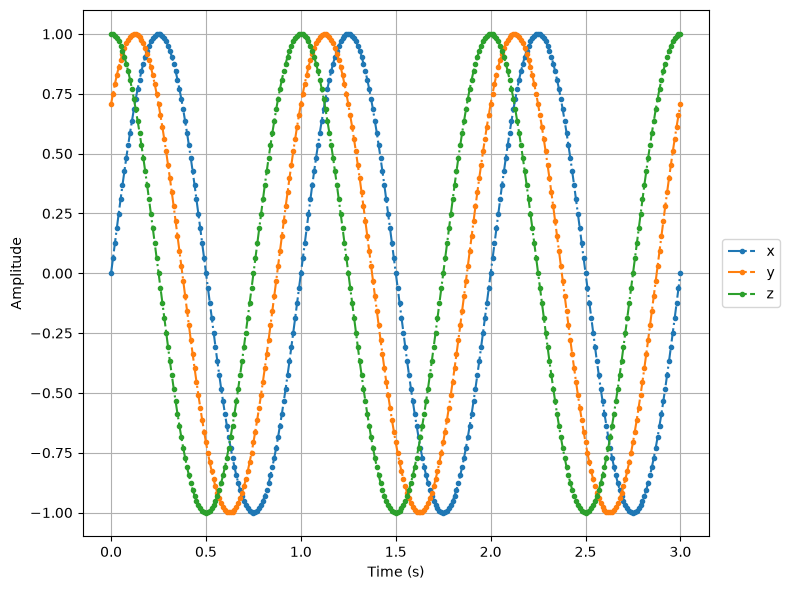

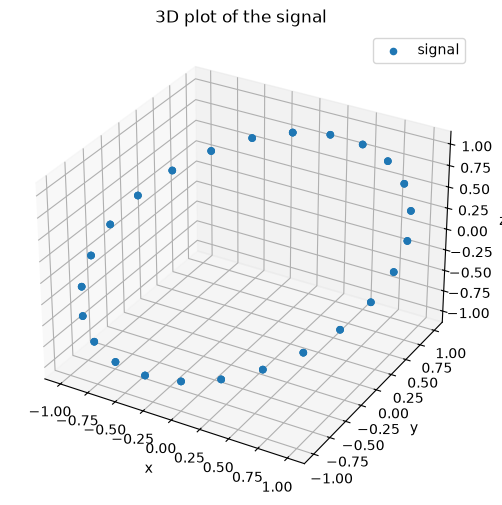

In [3]:
t, s = time, signal
print(f"t.shape = {t.shape}")
print(f"s.shape = {s.shape}")
print(f"phase_shift = {phase_shift / np.pi:g} pi")

# 2D 
fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(["x", "y", "z"]):
    ax.plot(t[:, 0], s[:, i], "-.", marker=".", label=label)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

# 3D 
fig = plt.figure(figsize=(6, 6))
ax3 = fig.add_subplot(projection="3d")
step = 4   # one point out of 4, to keep the trajectory readable
ax3.scatter(s[::step, 0], s[::step, 1], s[::step, 2], label="signal")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_title("3D plot of the signal")
ax3.legend()
plt.show()

## 2. Estimate the time derivative of the signal

### 2.1 Derivative of a sine wave

$$
\frac{d}{dt}\big[A\sin(2\pi f t + \varphi)\big] = 2\pi f A \cos(2\pi f t + \varphi)
$$

### 2.2 Time derivative of `signal` along each axis

With $A = 1$, $f = 1$ Hz and $\Delta\varphi = \pi/4$:

$$
\dot{x}(t) = 2\pi\cos(2\pi t), \qquad
\dot{y}(t) = 2\pi\cos\!\left(2\pi t + \tfrac{\pi}{4}\right), \qquad
\dot{z}(t) = 2\pi\cos\!\left(2\pi t + \tfrac{\pi}{2}\right)
$$

Each derivative oscillates between $-2\pi$ and $+2\pi \approx 6.28$.

### 2.3 Forward difference vs. central difference

| | Forward difference | Central difference |
|---|---|---|
| Formula | $\dot{s}_i \approx \dfrac{s_{i+1} - s_i}{t_{i+1} - t_i}$ | $\dot{s}_i \approx \dfrac{s_{i+1} - s_{i-1}}{t_{i+1} - t_{i-1}}$ |
| Accuracy | first order, error $O(h)$ | second order, error $O(h^2)$ |
| Time shift | half a sample (slope at $t_i + h/2$) | none (symmetric around $t_i$) |
| Missing values | last sample | first and last samples |

Missing edge values are filled with a one-sided difference.

**Reference:** https://en.wikipedia.org/wiki/Finite_difference

### 2.4 Design of the functions

- **Input order `(signal, time)`:** we differentiate the signal with respect to time ($d\,\text{signal}/d\,\text{time}$), the same order as `numpy.gradient`. Passing `time` instead of `fs` also handles irregular sampling.
- **Output shape = shape of `signal`** `(n_samples, n_dims)`: one derivative per sample and per axis, so it can be plotted against `time` directly.

In [4]:
def _as_2d(signal, time):
    # Helper: force signal to (n, d) and time to (n, 1), and check consistency.
    signal = np.asarray(signal, dtype=float)
    time = np.asarray(time, dtype=float)
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)
    time = time.reshape(-1, 1)
    if signal.shape[0] != time.shape[0]:
        raise ValueError("signal and time must have the same number of samples (rows)")
    if signal.shape[0] < 2:
        raise ValueError("at least 2 samples are needed to compute a derivative")
    return signal, time


def derivative_forward(signal, time):
    # Time derivative with the forward difference (first order, O(h)).
    #   ds/dt[i] = (s[i+1] - s[i]) / (t[i+1] - t[i])     for i = 0 .. n-2
    #   last sample: backward difference (s[n-1] - s[n-2]) / (t[n-1] - t[n-2])
    # Inputs : signal (n, d) samples over rows, dims over columns ; time (n,) or (n, 1)
    # Returns: numpy array of shape (n, d), same shape as signal.
    signal, time = _as_2d(signal, time)
    d = np.empty_like(signal)
    d[:-1] = (signal[1:] - signal[:-1]) / (time[1:] - time[:-1])
    d[-1] = d[-2]          # backward difference at the last sample (same quotient)
    return d

def derivative_central(signal, time):
    # Time derivative with the central difference (second order, O(h^2)).
    #   ds/dt[i] = (s[i+1] - s[i-1]) / (t[i+1] - t[i-1])  for i = 1 .. n-2
    #   first sample: forward difference ; last sample: backward difference
    # Inputs : signal (n, d) samples over rows, dims over columns ; time (n,) or (n, 1)
    # Returns: numpy array of shape (n, d), same shape as signal.
    signal, time = _as_2d(signal, time)
    d = np.empty_like(signal)
    if signal.shape[0] > 2:
        d[1:-1] = (signal[2:] - signal[:-2]) / (time[2:] - time[:-2])
    d[0] = (signal[1] - signal[0]) / (time[1] - time[0])
    d[-1] = (signal[-1] - signal[-2]) / (time[-1] - time[-2])
    return d

signal.shape = (301, 3) -> d_fwd.shape = (301, 3), d_cen.shape = (301, 3)
max |error| forward difference : 0.1974
max |error| central difference : 0.004133  (interior samples)
np.gradient agrees with derivative_central: True


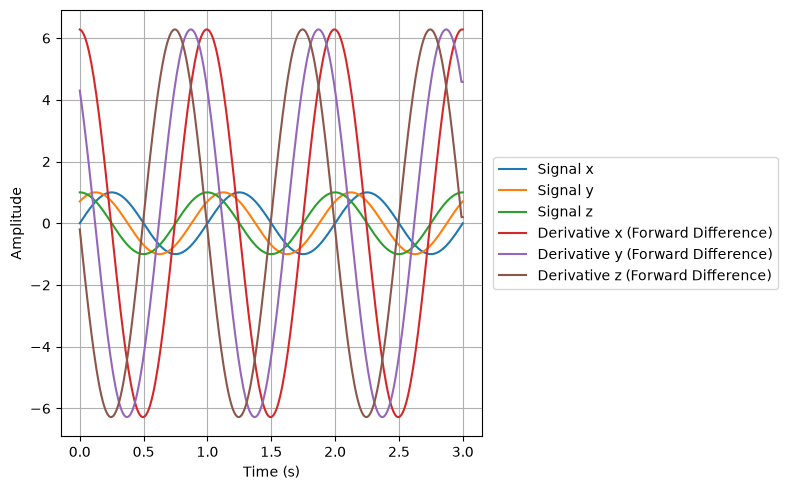

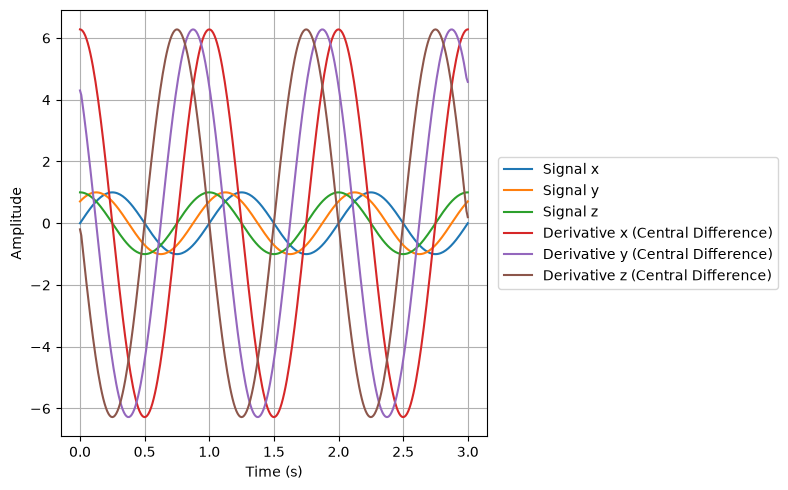

In [5]:
d_fwd = derivative_forward(signal, time)
d_cen = derivative_central(signal, time)
print(f"signal.shape = {signal.shape} -> d_fwd.shape = {d_fwd.shape}, d_cen.shape = {d_cen.shape}")

# Analytical derivative, to quantify the error of each method
d_true = 2 * np.pi * f * A * np.cos(2 * np.pi * f * time + phases)
print(f"max |error| forward difference : {np.max(np.abs(d_fwd - d_true)):.4f}")
print(f"max |error| central difference : {np.max(np.abs(d_cen[1:-1] - d_true[1:-1])):.6f}  (interior samples)")
print(f"np.gradient agrees with derivative_central: {np.allclose(d_cen, np.gradient(signal, time[:, 0], axis=0))}")

for deriv, name in [(d_fwd, "Forward Difference"), (d_cen, "Central Difference")]:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, ax_name in enumerate(["x", "y", "z"]):
        ax.plot(time, signal[:, i], label=f"Signal {ax_name}")
    for i, ax_name in enumerate(["x", "y", "z"]):
        ax.plot(time, deriv[:, i], label=f"Derivative {ax_name} ({name})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    plt.tight_layout()
    plt.show()

**Cells for Parts 3 and 4 (BINCHE Werner).** They use `signal`, `time`, `phases` and `derivative_central` defined in Parts 1–2, so they only run inside the shared notebook.